In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib 
matplotlib.rcParams['figure.figsize']=(15,7)

In [2]:
df1=pd.read_csv('Pune house data.csv')

In [3]:
df1.head()

,area_type,availability,size,society,total_sqft,bath,balcony,price,site_location
0,Super built-up Area,19-Dec,2 BHK,Coomee,1056,2.0,1.0,39.07,Alandi Road
1,Plot Area,Ready To Move,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,Ambegaon Budruk
2,Built-up Area,Ready To Move,3 BHK,NaN,1440,2.0,3.0,62.00,Anandnagar
3,Super built-up Area,Ready To Move,3 BHK,Soiewre,1521,3.0,1.0,95.00,Aundh
4,Super built-up Area,Ready To Move,2 BHK,NaN,1200,2.0,1.0,51.00,Aundh Road


In [4]:
df1.shape

(13320, 9)

In [5]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [6]:
#check null values
df1.isnull().sum()

area_type           0
availability        0
size               16
society          5502
total_sqft          0
bath               73
balcony           609
price               0
site_location       1
dtype: int64

In [7]:
#remove unwanted columns
df2= df1.drop(['society', 'availability'], axis='columns')
df2.head()

,area_type,size,total_sqft,bath,balcony,price,site_location
0,Super built-up Area,2 BHK,1056,2.0,1.0,39.07,Alandi Road
1,Plot Area,4 Bedroom,2600,5.0,3.0,120.00,Ambegaon Budruk
2,Built-up Area,3 BHK,1440,2.0,3.0,62.00,Anandnagar
3,Super built-up Area,3 BHK,1521,3.0,1.0,95.00,Aundh
4,Super built-up Area,2 BHK,1200,2.0,1.0,51.00,Aundh Road


In [8]:
#again check null values
df2.isnull().sum()
#balcony has more null values.

area_type          0
size              16
total_sqft         0
bath              73
balcony          609
price              0
site_location      1
dtype: int64

In [9]:
#checking count of unique values 
df2.groupby('balcony')['balcony'].agg('count')

balcony
0.0    1029
1.0    4897
2.0    5113
3.0    1672
Name: balcony, dtype: int64

In [10]:
#assume that null values means no balacony(0).

df2['balcony'] = df2['balcony'].fillna('0')
df2.isnull().sum()

area_type         0
size             16
total_sqft        0
bath             73
balcony           0
price             0
site_location     1
dtype: int64

In [11]:
#drop other null rows from the data.
df3=df2.dropna()
df3.shape

(13246, 7)

In [12]:
df3.isnull().sum()
#now dataset has no null values.

area_type        0
size             0
total_sqft       0
bath             0
balcony          0
price            0
site_location    0
dtype: int64

In [13]:
df3.head()
#size columns has to be neat.

,area_type,size,total_sqft,bath,balcony,price,site_location
0,Super built-up Area,2 BHK,1056,2.0,1.0,39.07,Alandi Road
1,Plot Area,4 Bedroom,2600,5.0,3.0,120.00,Ambegaon Budruk
2,Built-up Area,3 BHK,1440,2.0,3.0,62.00,Anandnagar
3,Super built-up Area,3 BHK,1521,3.0,1.0,95.00,Aundh
4,Super built-up Area,2 BHK,1200,2.0,1.0,51.00,Aundh Road


In [14]:
#check columns unique one-by-one to clean data.
df3['area_type'].unique()

#looks like area_type colum is clean.

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [15]:
#checking size column
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [16]:
#create new columns to only pic number from size.
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

C:\Users\manal\AppData\Local\Temp\ipykernel_27564\1796713648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))


In [17]:
df3.head()
#seperate columns of only number of bhk is created. Now drop size column.

,area_type,size,total_sqft,bath,balcony,price,site_location,bhk
0,Super built-up Area,2 BHK,1056,2.0,1.0,39.07,Alandi Road,2
1,Plot Area,4 Bedroom,2600,5.0,3.0,120.00,Ambegaon Budruk,4
2,Built-up Area,3 BHK,1440,2.0,3.0,62.00,Anandnagar,3
3,Super built-up Area,3 BHK,1521,3.0,1.0,95.00,Aundh,3
4,Super built-up Area,2 BHK,1200,2.0,1.0,51.00,Aundh Road,2


In [18]:
df4 = df3.drop('size', axis='columns')
df4['bhk'].unique()
#there are houses which contains more than 20 rooms.

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [19]:
#there are houses which contains more than 20 rooms. Lets check them how many houses are there.

df4[df4.bhk>20]

,area_type,total_sqft,bath,balcony,price,site_location,bhk
1718,Super built-up Area,8000,27.0,0.0,230.0,Uruli Devachi,27
4684,Plot Area,2400,40.0,0.0,660.0,Salunke Vihar,43


In [20]:
#checking total_sqft columns for cleaning.
df4['total_sqft'].unique()

#there are some values like (113-1384) in ranges.

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [21]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [22]:
df4[~df4['total_sqft'].apply(is_float)].head(10)


,area_type,total_sqft,bath,balcony,price,site_location,bhk
30,Super built-up Area,2100 - 2850,4.0,0.0,186.000,Gultekdi,4
122,Super built-up Area,3067 - 8156,4.0,0.0,477.000,Ganeshkhind,4
137,Super built-up Area,1042 - 1105,2.0,0.0,54.005,Khadaki,2
165,Super built-up Area,1145 - 1340,2.0,0.0,43.490,Prabhat Road,2
188,Super built-up Area,1015 - 1540,2.0,0.0,56.800,Wakadewadi,2
410,Super built-up Area,34.46Sq. Meter,1.0,0.0,18.500,Ganeshkhind,1
549,Super built-up Area,1195 - 1440,2.0,0.0,63.770,Prabhat Road,2
648,Built-up Area,4125Perch,9.0,0,265.000,Raviwar Peth,9
661,Super built-up Area,1120 - 1145,2.0,0.0,48.130,Tilak Road,2
672,Built-up Area,3090 - 5002,4.0,0.0,445.000,Alandi Road,4


In [23]:
#convert those to numbers
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens)==2:
        return(float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [24]:
#checking the function works properly
convert_sqft_to_num('2548-2825')

#return(float(tokens[0])+float(tokens[1]))/2

2686.5

In [25]:
convert_sqft_to_num('2548')
#return float(x)

2548.0

In [26]:
convert_sqft_to_num('4.46Sq. Meter')
#return None
#all works.

In [27]:
#apply it full column
df5 = df4.copy()
df5['total_sqft'] = df5['total_sqft'].apply(convert_sqft_to_num)
df5.head()

,area_type,total_sqft,bath,balcony,price,site_location,bhk
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2
1,Plot Area,2600.0,5.0,3.0,120.00,Ambegaon Budruk,4
2,Built-up Area,1440.0,2.0,3.0,62.00,Anandnagar,3
3,Super built-up Area,1521.0,3.0,1.0,95.00,Aundh,3
4,Super built-up Area,1200.0,2.0,1.0,51.00,Aundh Road,2


In [28]:
#check is it changed ot not
df5.loc[30]
#changed from 2100-2850 to 2475

area_type        Super built-up  Area
total_sqft                     2475.0
bath                              4.0
balcony                           0.0
price                           186.0
site_location                Gultekdi
bhk                                 4
Name: 30, dtype: object

In [29]:
df5.loc[410]
#changed from 34.46Sq. Meter to NaN.

area_type        Super built-up  Area
total_sqft                        NaN
bath                              1.0
balcony                           0.0
price                            18.5
site_location             Ganeshkhind
bhk                                 1
Name: 410, dtype: object

In [30]:
df5.isnull().sum()

area_type         0
total_sqft       46
bath              0
balcony           0
price             0
site_location     0
bhk               0
dtype: int64

In [31]:
#drop those null values.
df6 = df5.dropna()

In [32]:
df6.isnull().sum()

area_type        0
total_sqft       0
bath             0
balcony          0
price            0
site_location    0
bhk              0
dtype: int64

In [33]:
#now create a new colum price per sqft.
df6['price_per_sqft'] = df6['price']*100000 / df6['total_sqft']
df6.head(10)

C:\Users\manal\AppData\Local\Temp\ipykernel_27564\3074794784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df6['price_per_sqft'] = df6['price']*100000 / df6['total_sqft']


,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2,3699.810606
1,Plot Area,2600.0,5.0,3.0,120.00,Ambegaon Budruk,4,4615.384615
2,Built-up Area,1440.0,2.0,3.0,62.00,Anandnagar,3,4305.555556
3,Super built-up Area,1521.0,3.0,1.0,95.00,Aundh,3,6245.890861
4,Super built-up Area,1200.0,2.0,1.0,51.00,Aundh Road,2,4250.000000
5,Super built-up Area,1170.0,2.0,1.0,38.00,Balaji Nagar,2,3247.863248
6,Super built-up Area,2732.0,4.0,0,204.00,Baner,4,7467.057101
7,Super built-up Area,3300.0,4.0,0,600.00,Baner road,4,18181.818182
8,Super built-up Area,1310.0,3.0,1.0,63.25,Bhandarkar Road,3,4828.244275
9,Plot Area,1020.0,6.0,0,370.00,Bhavani Peth,6,36274.509804


In [34]:
#continue checking of other columns.
df6['bath'].unique()

#there is 40 bathrooms, it is unusual but in this data there 40bhk house also there,so leave this.

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [35]:
df6['site_location'].unique()
#its fine.

array(['Alandi Road', 'Ambegaon Budruk', 'Anandnagar', 'Aundh',
       'Aundh Road', 'Balaji Nagar', 'Baner', 'Baner road',
       'Bhandarkar Road', 'Bhavani Peth', 'Bibvewadi', 'Bopodi',
       'Budhwar Peth', 'Bund Garden Road', 'Camp', 'Chandan Nagar',
       'Dapodi', 'Deccan Gymkhana', 'Dehu Road', 'Dhankawadi',
       'Dhayari Phata', 'Dhole Patil Road', 'Erandwane', 'Fatima Nagar',
       'Fergusson College Road', 'Ganesh Peth', 'Ganeshkhind',
       'Ghorpade Peth', 'other', 'Gokhale Nagar', 'Gultekdi',
       'Guruwar peth', 'Hadapsar', 'Hadapsar Industrial Estate',
       'Hingne Khurd', 'Jangali Maharaj Road', 'Kalyani Nagar',
       'Karve Nagar', 'Karve Road', 'Kasba Peth', 'Katraj', 'Khadaki',
       'Khadki', 'Kharadi', 'Kondhwa', 'Kondhwa Budruk', 'Kondhwa Khurd',
       'Koregaon Park', 'Kothrud', 'Law College Road', 'Laxmi Road',
       'Lulla Nagar', 'Mahatma Gandhi Road', 'Mangalwar peth',
       'Manik Bagh', 'Market yard', 'Mukund Nagar', 'Mundhawa',
       'Naga

In [36]:
df6.head()
#all data columns are looks fine.
#now move to check outliers.

,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2,3699.810606
1,Plot Area,2600.0,5.0,3.0,120.00,Ambegaon Budruk,4,4615.384615
2,Built-up Area,1440.0,2.0,3.0,62.00,Anandnagar,3,4305.555556
3,Super built-up Area,1521.0,3.0,1.0,95.00,Aundh,3,6245.890861
4,Super built-up Area,1200.0,2.0,1.0,51.00,Aundh Road,2,4250.000000


In [37]:
df6.shape

(13200, 8)

In [38]:
#outliers are found in only numeric columns.
#note there is usual sqft of 1bhk is more than 300. check whether is any less than 300.
df6[df6.total_sqft/df6.bhk<300]

#correct there are some house which cann't believe. so remove them from data.

,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
9,Plot Area,1020.0,6.0,0,370.0,Bhavani Peth,6,36274.509804
45,Plot Area,600.0,9.0,0,200.0,Kondhwa Budruk,8,33333.333333
58,Plot Area,1407.0,4.0,1.0,150.0,Mundhawa,6,10660.980810
68,Plot Area,1350.0,7.0,0.0,85.0,Pirangut,8,6296.296296
70,Plot Area,500.0,3.0,2.0,100.0,Pune Railway Station,3,20000.000000
...,...,...,...,...,...,...,...,...
13277,Plot Area,1400.0,7.0,0,218.0,Ghorpadi,7,15571.428571
13279,Plot Area,1200.0,5.0,0,130.0,Gultekdi,6,10833.333333
13281,Plot Area,1375.0,5.0,1.0,125.0,Hadapsar,5,9090.909091
13303,Plot Area,774.0,5.0,3.0,70.0,Manik Bagh,5,9043.927649


In [39]:
df7 = df6[~(df6.total_sqft/df6.bhk<300)]


In [40]:
df7.head()

,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2,3699.810606
1,Plot Area,2600.0,5.0,3.0,120.00,Ambegaon Budruk,4,4615.384615
2,Built-up Area,1440.0,2.0,3.0,62.00,Anandnagar,3,4305.555556
3,Super built-up Area,1521.0,3.0,1.0,95.00,Aundh,3,6245.890861
4,Super built-up Area,1200.0,2.0,1.0,51.00,Aundh Road,2,4250.000000


In [41]:
df7.shape

(12456, 8)

In [42]:
df7.price_per_sqft.describe()

#min is 267 
#max is 176470, it is unbelivable for one sqft.

count     12456.000000
mean       6308.628922
std        4168.075333
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [43]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('site_location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index = True)
    return df_out

df8 = remove_pps_outliers(df7)

In [44]:
df8.shape

(10883, 8)

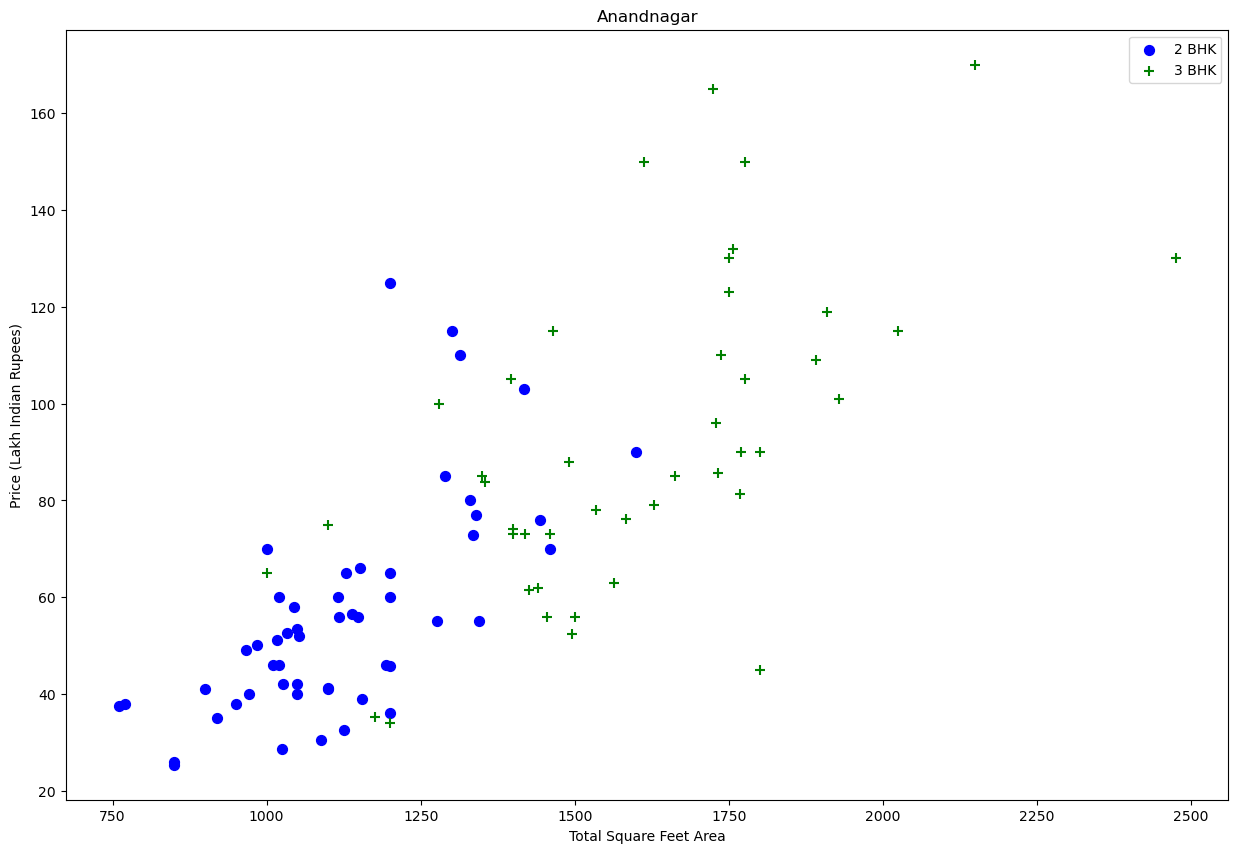

In [45]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.site_location==location) & (df.bhk==2)]
    bhk3 = df[(df.site_location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df8,"Anandnagar")
#some house price have 3 bhk there prices are less 2 bhk house.

In [46]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('site_location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean' : np.mean(bhk_df.price_per_sqft),
                'std' : np.std(bhk_df.price_per_sqft),
                'count' : bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis ='index')

df9 = remove_bhk_outliers(df8)

In [47]:
df9.shape

(7543, 8)

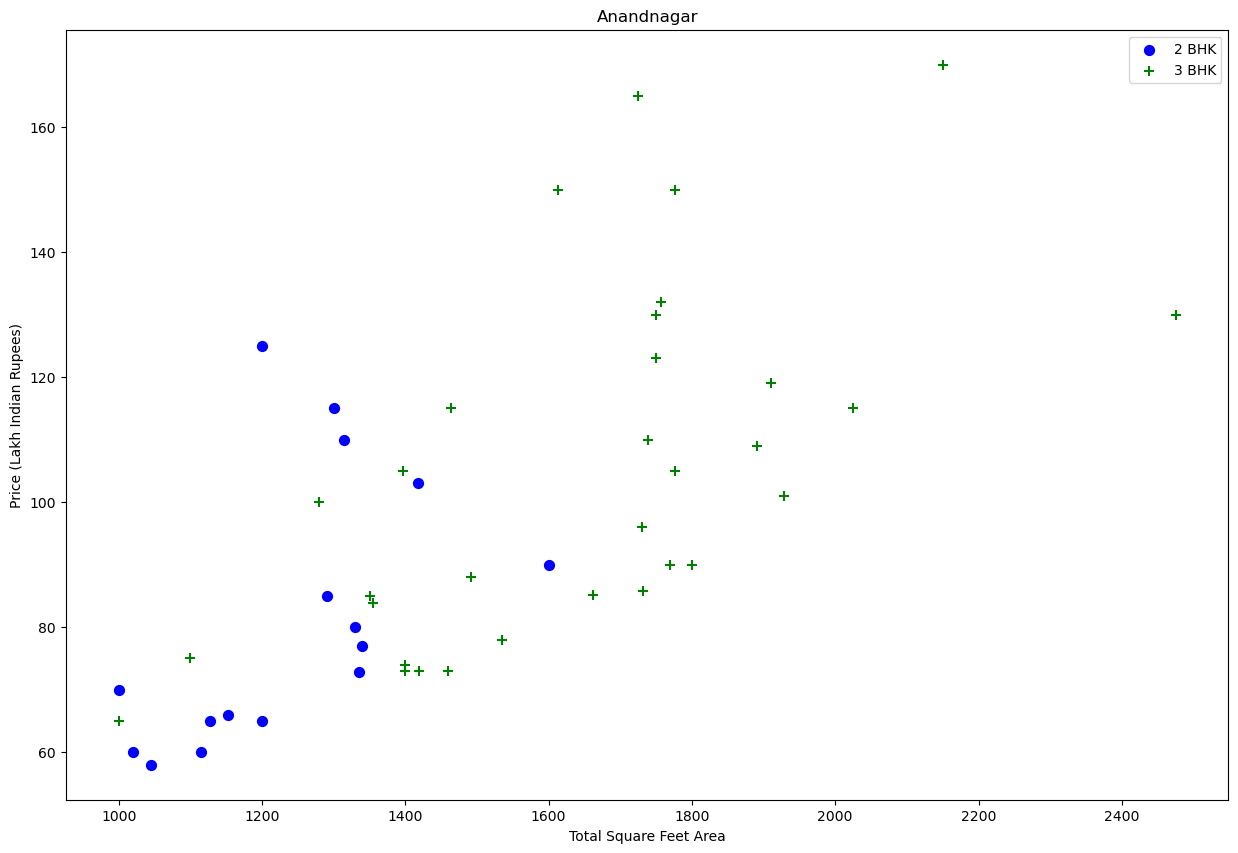

In [48]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.site_location==location) & (df.bhk==2)]
    bhk3 = df[(df.site_location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df9,"Anandnagar")
#some outliers are removed.

Text(0, 0.5, 'Count')

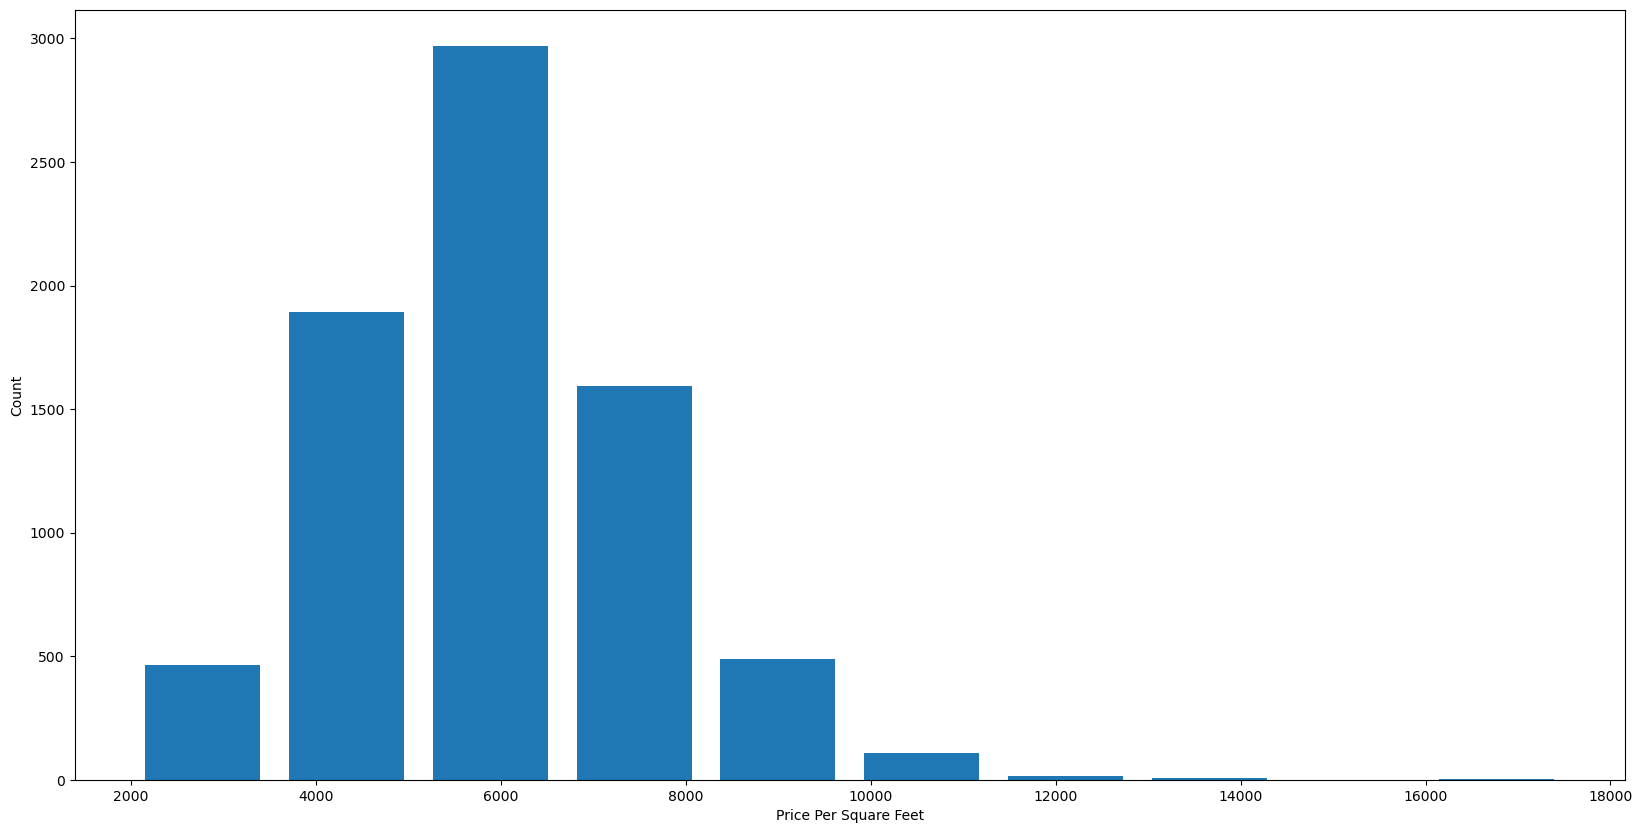

In [49]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df9.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [50]:
df9.bath.unique()

array([ 2.,  4.,  3.,  5.,  9.,  1.,  6.,  7.,  8., 12., 13., 16.])

Text(0, 0.5, 'count')

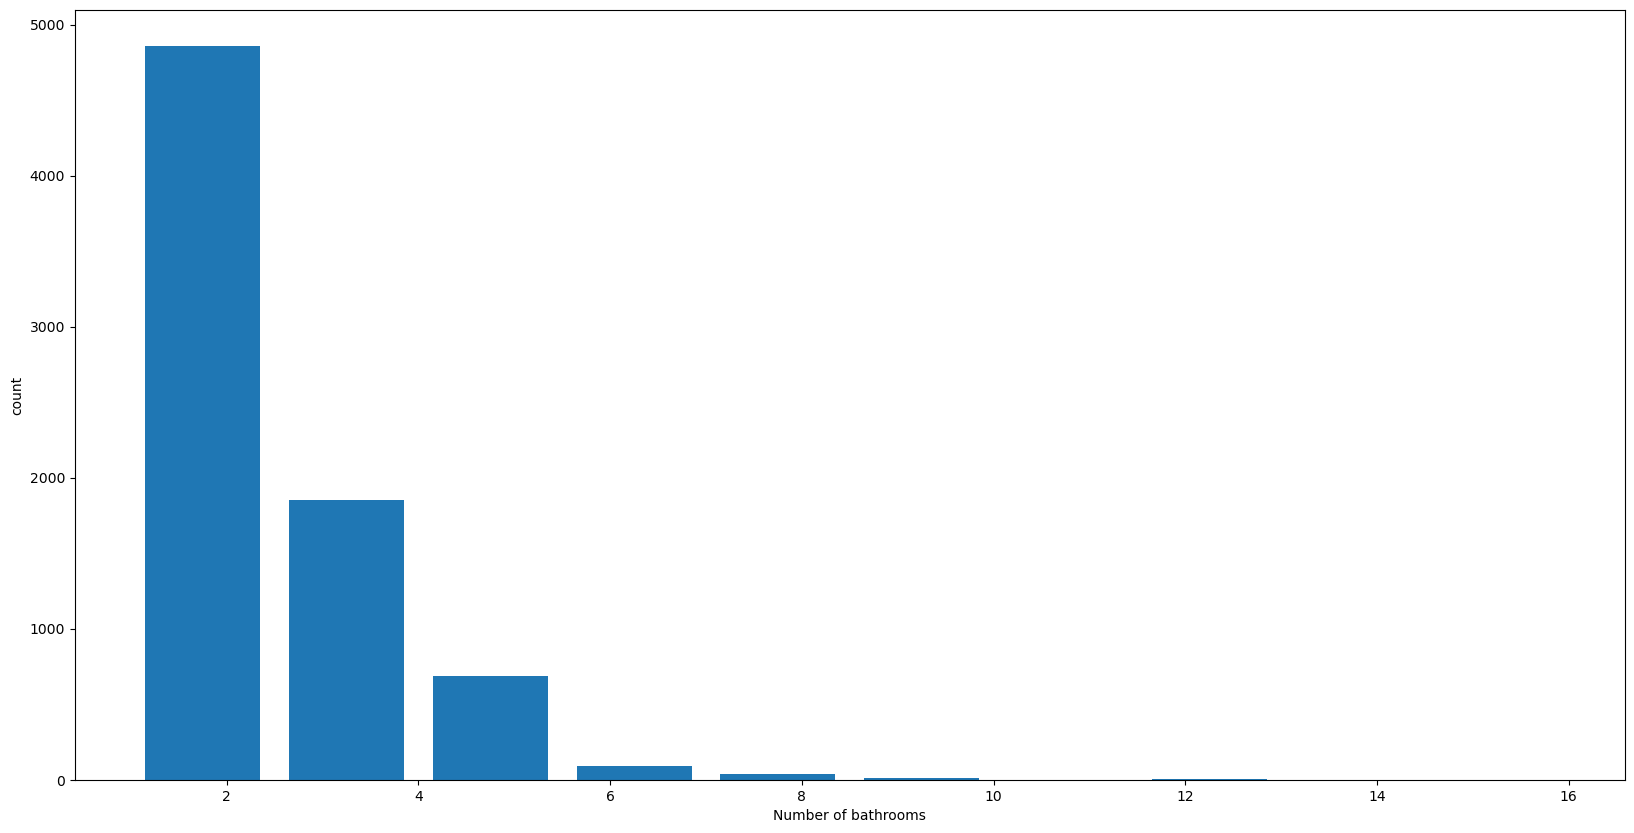

In [51]:
plt.hist(df9.bath, rwidth=0.8)
plt.xlabel('Number of bathrooms')
plt.ylabel('count')

In [52]:
df9[df9.bath>10]

,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
1211,Super built-up Area,6000.0,12.0,0,150.0,Bibvewadi,11,2500.000000
2637,Super built-up Area,12000.0,12.0,0,525.0,Fatima Nagar,10,4375.000000
5265,Super built-up Area,5425.0,13.0,0.0,275.0,Kondhwa Khurd,13,5069.124424
6350,Super built-up Area,10000.0,16.0,0,550.0,Model colony,16,5500.000000
10389,Super built-up Area,4000.0,12.0,0,160.0,Wagholi,10,4000.000000


In [53]:
#some house have bathrooms more than rooms, it is belivable if 1 extra is there, but if more 1 extra is unbelivable.

df9[df9.bath>df9.bhk+2]

#is there. drop them.


,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
772,Super built-up Area,1806.0,6.0,2.0,116.0,Baner,3,6423.034330
3067,Super built-up Area,11338.0,9.0,1.0,1000.0,Ghorpade Peth,6,8819.897689
4231,Built-up Area,7000.0,8.0,0,450.0,Karve Nagar,4,6428.571429


In [54]:
df10= df9[df9.bath<df9.bhk+2]

In [55]:
df10.shape

(7479, 8)

In [56]:
df10.head()

,area_type,total_sqft,bath,balcony,price,site_location,bhk,price_per_sqft
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2,3699.810606
1,Plot Area,2894.0,4.0,1.0,245.00,Alandi Road,4,8465.791292
2,Super built-up Area,1084.0,2.0,2.0,50.00,Alandi Road,2,4612.546125
3,Super built-up Area,1230.0,2.0,2.0,80.00,Alandi Road,2,6504.065041
4,Super built-up Area,1750.0,3.0,2.0,130.00,Alandi Road,3,7428.571429


In [57]:
#all data are clear now.
#remove price_per_sqft.
df11 = df10.drop('price_per_sqft', axis='columns')

In [58]:
df11.shape

(7479, 7)

In [59]:
df11.head()

,area_type,total_sqft,bath,balcony,price,site_location,bhk
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2
1,Plot Area,2894.0,4.0,1.0,245.00,Alandi Road,4
2,Super built-up Area,1084.0,2.0,2.0,50.00,Alandi Road,2
3,Super built-up Area,1230.0,2.0,2.0,80.00,Alandi Road,2
4,Super built-up Area,1750.0,3.0,2.0,130.00,Alandi Road,3


In [60]:
location_dummies = pd.get_dummies(df11.site_location)


In [61]:
location_dummies.head()

,Alandi Road,Ambegaon Budruk,Anandnagar,Aundh,Aundh Road,Balaji Nagar,Baner,Baner road,Bhandarkar Road,Bhavani Peth,...,Uruli Devachi,Vadgaon Budruk,Viman Nagar,Vishrant Wadi,Wadgaon Sheri,Wagholi,Wakadewadi,Wanowrie,Warje,Yerawada
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [62]:
area_type_dummies = pd.get_dummies(df11.area_type)


In [63]:
area_type_dummies.head()

,Built-up Area,Carpet Area,Plot Area,Super built-up Area
0,False,False,False,True
1,False,False,True,False
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True


In [64]:
df12 = pd.concat([df11, location_dummies.drop('Yerawada', axis='columns'), area_type_dummies.drop('Built-up  Area', axis='columns')], axis='columns')

In [65]:
df12.head()

,area_type,total_sqft,bath,balcony,price,site_location,bhk,Alandi Road,Ambegaon Budruk,Anandnagar,...,Viman Nagar,Vishrant Wadi,Wadgaon Sheri,Wagholi,Wakadewadi,Wanowrie,Warje,Carpet Area,Plot Area,Super built-up Area
0,Super built-up Area,1056.0,2.0,1.0,39.07,Alandi Road,2,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1,Plot Area,2894.0,4.0,1.0,245.00,Alandi Road,4,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,Super built-up Area,1084.0,2.0,2.0,50.00,Alandi Road,2,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,Super built-up Area,1230.0,2.0,2.0,80.00,Alandi Road,2,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,Super built-up Area,1750.0,3.0,2.0,130.00,Alandi Road,3,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [66]:
df13 = df12.drop(['site_location', 'area_type'], axis='columns')


In [67]:
df13.head()

,total_sqft,bath,balcony,price,bhk,Alandi Road,Ambegaon Budruk,Anandnagar,Aundh,Aundh Road,...,Viman Nagar,Vishrant Wadi,Wadgaon Sheri,Wagholi,Wakadewadi,Wanowrie,Warje,Carpet Area,Plot Area,Super built-up Area
0,1056.0,2.0,1.0,39.07,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2894.0,4.0,1.0,245.00,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1084.0,2.0,2.0,50.00,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1230.0,2.0,2.0,80.00,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1750.0,3.0,2.0,130.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [68]:
df13.shape

(7479, 103)

In [69]:
X = df13.drop('price', axis='columns')


In [70]:
X.head()

,total_sqft,bath,balcony,bhk,Alandi Road,Ambegaon Budruk,Anandnagar,Aundh,Aundh Road,Balaji Nagar,...,Viman Nagar,Vishrant Wadi,Wadgaon Sheri,Wagholi,Wakadewadi,Wanowrie,Warje,Carpet Area,Plot Area,Super built-up Area
0,1056.0,2.0,1.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2894.0,4.0,1.0,4,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,1084.0,2.0,2.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1230.0,2.0,2.0,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1750.0,3.0,2.0,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [71]:
y=df13.price


In [72]:
y.head()

0     39.07
1    245.00
2     50.00
3     80.00
4    130.00
Name: price, dtype: float64

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=10)

In [74]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()

In [75]:
lr_clf.fit(X_train, y_train)


LinearRegression()

In [76]:
lr_clf.score(X_test, y_test)

0.8266219762170621

In [77]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.87665675, 0.87440397, 0.83065346, 0.89738279, 0.81673248])

In [78]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

In [79]:
def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_regression' : {
            'model': LinearRegression(),
            'params': {
                'normalize': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion' : ['mse','friedman_mse'],
                'splitter': ['best','random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score','best_params'])



In [83]:
find_best_model_using_gridsearchcv(X,y)

ValueError: Invalid parameter 'normalize' for estimator LinearRegression(). Valid parameters are: ['copy_X', 'fit_intercept', 'n_jobs', 'positive'].

In [84]:
def predict_price(location,sqft,bath,bhk):    
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1

    return lr_clf.predict([x])[0]

In [85]:
predict_price('Alandi Road', 1000,2,2)

C:\Users\manal\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


57.94733221323074

In [86]:
import joblib

In [87]:
joblib.dump(lr_clf, 'Pune_Price_Prediction.pkl')

['Pune_Price_Prediction.pkl']

In [90]:
df1.location()


AttributeError: 'DataFrame' object has no attribute 'location'

In [91]:
predict_price('Baner', 800,2,2)

C:\Users\manal\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


42.39974242216533